# Temperature at the Tap

## Learning Objectives

- Read the undisturbed soil temperature at pipe depth off a surface weather record, and see how
  depth damps the swing and delays it
- Separate the classical one-way relaxation from the two-way correction the pipe's own heat makes
  to the soil around it
- See why the wall heat has to be booked over the time water actually spends in a pipe, and what
  that changes for a branch that stands still overnight
- Reconstruct the produced temperature from tap measurements, and read the model's own statement
  of which bins it will not answer

## Theoretical background

### Relaxation toward a moving target

A parcel of water in a buried pipe obeys Newton's law of cooling toward the temperature of the
soil around it,

$$\frac{dT}{dt} = -h\,\bigl(T - T_b(t)\bigr),$$

with $h$ [1/day] the exchange rate: the series resistance of the water-side film, the pipe wall
and the soil, divided by the heat capacity of the water column. This is first-order decay toward
a *moving target* instead of toward zero, so the delivered temperature is an **affine** reading of
the same transport operator the rest of the package uses,

$$T_\mathrm{out} = W\,T_\mathrm{in} + b,$$

with $W$ built with $h$ in the decay-rate slot and $b$ the soil's contribution accumulated along
each path. Everything below is a way of asking what $T_b$ is.

### The soil is not a boundary condition, it is a memory

If the pipe were a passive thermometer, $T_b$ would be the *undisturbed* soil temperature at pipe
depth — the half-space response to the weather at the surface. That is the classical one-way
model, and `max_sweeps=1` returns exactly it.

But a pipe that has been losing heat for a week has warmed the ground around it, and it then
exchanges against that warmer halo rather than against undisturbed soil. Splitting the wall's
response into a **steady part plus a transient deficit** turns the two-way problem back into the
one-way problem with a shifted target,

$$T_{b,e}[n] = T_\infty[n] - \sum_{j \le n} \Delta\psi_e[j]\,\bar{D}[n-j],$$

one convolution of the segment's own wall-flux history $\psi$ per segment. The two-way answer is
the fixed point of alternating a transport pass, a flux pass and this convolution.

### Where the heat is booked

The flux $\psi$ of a bin is the segment's own **enthalpy budget** over that bin: what it advected
in, minus what it advected out, minus the change in what it is holding. That matters most where
it is least obvious. Water standing in a pipe overnight exchanges heat for as long as it stands,
and a bin with no throughflow still leaks $-h(H - V T_b)$ into the soil. Charging that heat
instead to the single bin the water finally leaves in would overstate that bin by the ratio of
the standing time to the transit — which is the difference between a model that settles when you
refine it and one that does not.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from pipetransport import plot
from pipetransport.examples import example_demand, example_network
from pipetransport.heat import (
    endmember_to_source,
    segment_heat_rate,
    soil_temperature,
    sol_air_temperature,
    source_to_endmember,
)
from pipetransport.network import PipeNetwork

SOIL = pd.DataFrame(
    {"alpha": [0.05, 0.07], "kappa": [0.025, 0.035], "eta": [0.41, 0.41]},
    index=["grass", "paved"],
)


def sol_air(air, sun, *, absorptivity, latent):
    """Sol-air temperature: air, plus absorbed sunlight, less longwave and evaporation.

    ``sun`` is in W/m²; the 0.0207 converts W/m² to the package's K·m/day. The longwave term
    is a net 30 W/m² and the latent term is a fraction of the sunshine, which is the greater
    part of why grass runs cooler than pavement.
    """
    return sol_air_temperature(
        air_temperature=air,
        solar_irradiance=sun * 0.0207,
        absorptivity=absorptivity,
        eta=0.41,
        heat_loss=(30.0 + latent * sun) * 0.0207,
    )

## 1. The network and what it is buried under

The same seven-segment example network the water-quality notebook uses, with two extra columns
the heat pair needs: the land cover over each pipe and its burial depth. `cover` keys into a soil
table of thermal properties; pavement is given both a higher diffusivity and a higher conductivity
than grass.

In [2]:
segments = example_network().segments.copy()
segments["cover"] = ["grass", "grass", "paved", "paved", "grass", "paved", "grass"]
segments["depth"] = [1.2, 1.0, 1.0, 0.9, 1.0, 1.0, 0.8]
network = PipeNetwork(segments=segments, source="Plant")

print(network.segments[["length", "diameter", "volume", "cover", "depth"]].round(2))
print()
print(SOIL)

         length  diameter  volume  cover  depth
Plant-A  2000.0      0.40  251.33  grass    1.2
A-B      1500.0      0.30  106.03  grass    1.0
A-C      1200.0      0.25   58.90  paved    1.0
B-T1      800.0      0.15   14.14  paved    0.9
B-T2      400.0      0.20   12.57  grass    1.0
C-T3      600.0      0.15   10.60  paved    1.0
C-T4     2500.0      0.10   19.63  grass    0.8

       alpha  kappa   eta
grass   0.05  0.025  0.41
paved   0.07  0.035  0.41


## 2. From the weather to the soil at pipe depth

The undisturbed field is the superposition of Robin-boundary step responses of the half space,
driven by the sol-air temperature — the air temperature plus the absorbed sunlight, less what the
surface loses to the sky and to evaporation.

At pipe depth the diurnal signal is essentially gone: the damping depth $\sqrt{\alpha P/\pi}$ is
about 0.13 m for grass at a one-day period, so a metre of soil damps the daily swing by $e^{-7.9}$.
What survives is the *seasonal* wave, damped and delayed. Two years of daily weather, the second
read at three depths:

In [3]:
year_tedges = pd.date_range("2023-06-15", "2025-06-15", freq="D")
day = np.arange(len(year_tedges) - 1)
season = 10.5 + 8.5 * np.sin(2 * np.pi * (day - 45 + 91.25) / 365.0)  # air peaks end of July
sun = 300.0 * np.clip(np.sin(2 * np.pi * (day - 6 + 91.25) / 365.0), 0.0, None)  # daily mean W/m2

year_surface = {
    "grass": sol_air(season, sun, absorptivity=0.25, latent=0.35),
    "paved": sol_air(season, sun, absorptivity=0.90, latent=0.0),
}

settled = slice(365, None)  # drop the first year: the soil starts undisturbed and has to warm up
rows, fields = [], {}
for cover, alpha in (("grass", 0.05), ("paved", 0.07)):
    for depth in (0.5, 1.0, 2.0):
        field = soil_temperature(
            surface_temperature=year_surface[cover],
            tedges=year_tedges,
            depth=depth,
            alpha=alpha,
            kappa=float(SOIL.loc[cover, "kappa"]),
            eta=0.41,
        )
        fields[cover, depth] = field
        rows.append({
            "cover": cover,
            "depth [m]": depth,
            "mean [C]": field[settled].mean(),
            "swing [K]": field[settled].max() - field[settled].min(),
            "lag [days]": int(np.argmax(field[settled])) - int(np.argmax(year_surface[cover][settled])),
        })

print(f"sol-air annual mean [C]: { {c: round(v.mean(), 2) for c, v in year_surface.items()} }")
print(f"sol-air annual swing [K]: { {c: round(np.ptp(v), 1) for c, v in year_surface.items()} }")
print()
print(pd.DataFrame(rows).round(2).to_string(index=False))

sol-air annual mean [C]: {'grass': np.float64(8.51), 'paved': np.float64(13.35)}
sol-air annual swing [K]: {'grass': np.float64(15.9), 'paved': np.float64(29.5)}

cover  depth [m]  mean [C]  swing [K]  lag [days]
grass        0.5      8.84      12.64          14
grass        1.0      9.12      10.34          26
grass        2.0      9.68       6.95          49
paved        0.5     14.19      24.25          11
paved        1.0     14.90      20.59          20
paved        2.0     16.30      14.96          39


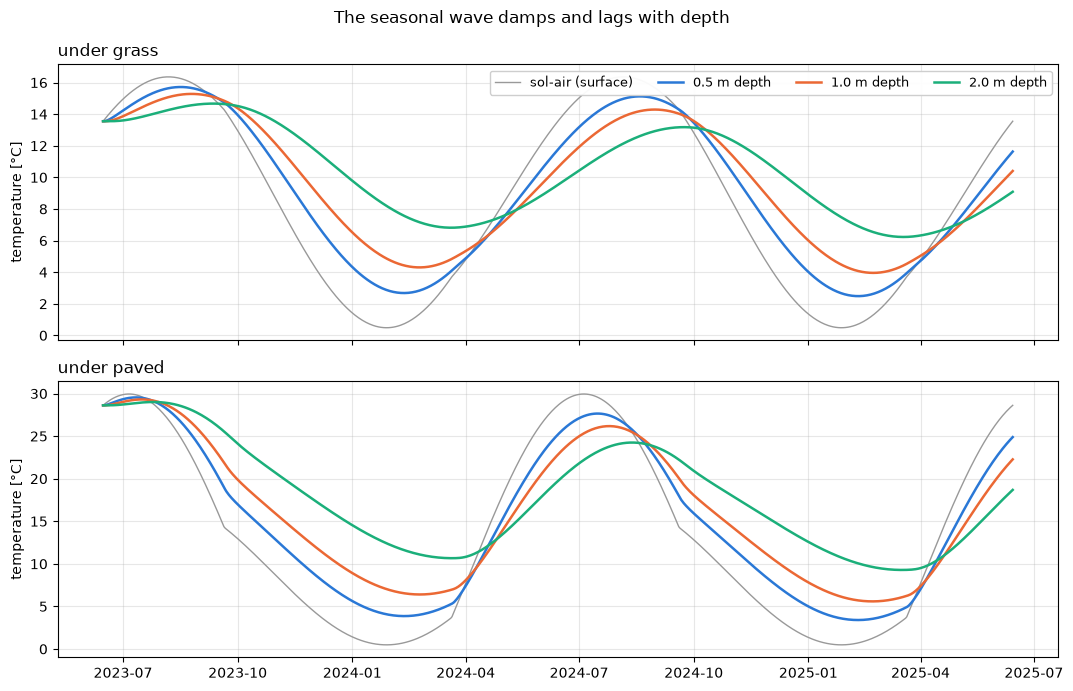

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
days = year_tedges[:-1]
for ax, cover in zip(axes, ("grass", "paved"), strict=True):
    ax.plot(days, year_surface[cover], color="0.6", lw=1.0, label="sol-air (surface)")
    for depth, color in zip((0.5, 1.0, 2.0), plot.series_colors(3), strict=True):
        ax.plot(days, fields[cover, depth], color=color, lw=1.8, label=f"{depth:.1f} m depth")
    ax.set_ylabel("temperature [°C]")
    ax.set_title(f"under {cover}", loc="left")
    ax.grid(alpha=0.3)
axes[0].legend(loc="upper right", ncol=4, fontsize=9, framealpha=0.95)
axes[1].set_xlabel("")
fig.suptitle("The seasonal wave damps and lags with depth", y=0.98)
fig.tight_layout()

Deeper is flatter and later, and the two covers differ by more than their surfaces do only
because pavement conducts better as well as absorbing more. The first year is discarded on
purpose: the model starts the soil undisturbed, and at a metre that assumption takes a season to
pay off — which is the same reason the network run below opens its record three weeks before the
window of interest.

## 3. What arrives at the taps

Every input lives on one `tedges` grid, so warming the model up means *starting the grid early*.
Three weeks — the $d_\mathrm{eff}^2/\alpha$ over which the halo kernel decays — is what the
network's own halo needs: without it the model opens onto undisturbed soil, as if every pipe had
been laid that morning. The output grid is free, so `cout_tedges` covers the fortnight of interest
and nothing has to be discarded afterwards. (The third memory, the water standing in the pipes, is
the automatic `spinup`.)

Three weeks does *not* settle the soil field itself. At a metre only about half of any surface
change has arrived by then, and the rest still leans on the record's first value — which is why
section 2 needed two years to show the seasonal wave. Read the halo *correction* below rather than
the absolute delivered temperature, and give a real study a record that reaches back seasons.

`max_sweeps=1` is the classical one-way model; the default is the two-way fixed point, and the
difference between them is the halo the network has built in its own soil.

In [5]:
lead_in = 21  # days: d_eff^2 / alpha, the span over which the halo kernel decays
tedges = pd.date_range("2025-05-11", periods=(lead_in + 14) * 24 + 1, freq="h")
cout_tedges = tedges[lead_in * 24 :]  # report on the fortnight of interest, 1-15 June
sh = np.arange(len(tedges) - 1)
doy = sh / 24.0 - (lead_in + 14)  # days from 15 June, so the seasonal term matches section 2
air = 10.5 + 8.5 * np.sin(2 * np.pi * (doy - 45 + 91.25) / 365.0) + 5.0 * np.sin(2 * np.pi * (sh - 9) / 24.0)
noon = 800.0 * np.clip(np.sin(2 * np.pi * (sh - 6) / 24.0), 0.0, None)
surface = {
    "grass": sol_air(air, noon, absorptivity=0.25, latent=0.35),
    "paved": sol_air(air, noon, absorptivity=0.90, latent=0.0),
}

hours = np.arange(len(tedges) - 1)
demand = example_demand(tedges=tedges, network=network)

transit = segments["volume"] / network.segment_flow(flow=demand).mean(axis=1)
rate = segment_heat_rate(
    network=network,
    kappa=pd.Series(SOIL["kappa"].reindex(segments["cover"]).to_numpy(), index=segments.index),
    depth=segments["depth"],
    eta=0.41,
)
print(
    pd.DataFrame({
        "h [1/day]": rate.round(2),
        "transit [h]": (transit * 24).round(2),
        "h*tau [-]": (rate.to_numpy() * transit).round(2),
    }).to_string()
)

         h [1/day]  transit [h]  h*tau [-]
Plant-A       0.49         7.54       0.15
A-B           0.84         4.24       0.15
A-C           1.57         7.07       0.46
B-T1          3.81         1.41       0.22
B-T2          1.64         0.84       0.06
C-T3          3.70         2.12       0.33
C-T4          5.65         5.89       1.39


`h*tau` is the fraction of the way to the soil a pipe takes its water: the trunk main barely
moves it, while the long thin branch to T4 nearly equilibrates. Thin pipes lose their water's
temperature for the same reason they lose chlorine — surface per unit volume.

In [6]:
tin = 11.0 + 1.5 * np.sin(2 * np.pi * hours / (24 * 7))
NODES = ["T1", "T4"]

one_way = source_to_endmember(
    tin=tin,
    flow=demand,
    tedges=tedges,
    cout_tedges=cout_tedges,
    network=network,
    soil=SOIL,
    surface_temperature=surface,
    report_nodes=NODES,
    max_sweeps=1,  # the classical one-way model: relax toward the undisturbed field
)
two_way = source_to_endmember(
    tin=tin,
    flow=demand,
    tedges=tedges,
    cout_tedges=cout_tedges,
    network=network,
    soil=SOIL,
    surface_temperature=surface,
    report_nodes=NODES,
)

for i, node in enumerate(NODES):
    print(
        f"{node}: produced {tin.min():.1f}-{tin.max():.1f} C, "
        f"delivered {np.nanmin(two_way[i]):.2f}-{np.nanmax(two_way[i]):.2f} C, "
        f"halo correction up to {np.nanmax(np.abs(two_way[i] - one_way[i])):.2f} K"
    )

T1: produced 9.5-12.5 C, delivered 11.14-13.86 C, halo correction up to 0.98 K
T4: produced 9.5-12.5 C, delivered 9.78-11.69 C, halo correction up to 0.80 K


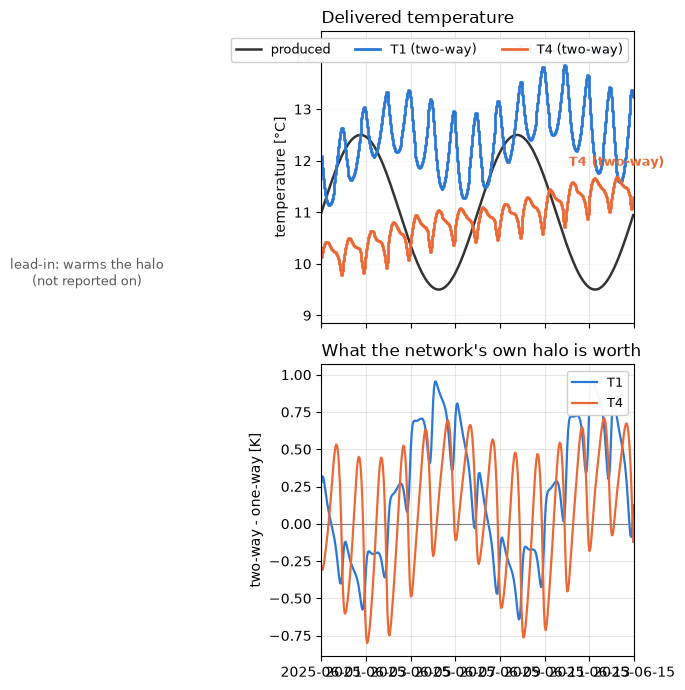

In [7]:
fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)
axes[0].plot(tedges[:-1], tin, color="0.2", lw=1.8, label="produced")
plot.endmember_series(
    values=dict(zip(("T1 (two-way)", "T4 (two-way)"), two_way, strict=True)),
    tedges=cout_tedges,
    ylabel="temperature [°C]",
    ax=axes[0],
)
axes[0].axvspan(tedges[0], cout_tedges[0], color="0.92", zorder=0)
axes[0].text(
    tedges[lead_in * 12],
    tin.min(),
    "lead-in: warms the halo\n(not reported on)",
    va="bottom",
    ha="center",
    fontsize=9,
    color="0.35",
)
axes[0].set_title("Delivered temperature", loc="left")
axes[0].legend(loc="upper right", ncol=3, fontsize=9, framealpha=0.95)
axes[0].grid(alpha=0.3)

for i, (node, color) in enumerate(zip(("T1", "T4"), plot.series_colors(2), strict=True)):
    axes[1].plot(cout_tedges[:-1], two_way[i] - one_way[i], color=color, lw=1.6, label=node)
axes[1].axhline(0.0, color="0.5", lw=0.8)
axes[1].set_ylabel("two-way - one-way [K]")
axes[1].set_title("What the network's own halo is worth", loc="left")
axes[1].legend(loc="upper right", fontsize=9, framealpha=0.95)
axes[1].grid(alpha=0.3)
fig.tight_layout()

The correction has a sign, and it is not the one a "the pipe has warmed its surroundings" picture
suggests. The target is an *effective driving temperature*, not a wall temperature: the exchange
rate keeps the fully developed soil resistance, which understates how fast a pipe exchanges while
its halo is still building, so the target has to be pushed *past* the undisturbed soil to make up
the difference. On average, then, the two-way model moves the delivered temperature further
**toward** the soil than the one-way model does — at both taps.

With three weeks of history behind it, though, the correction is no longer the one-sided
switch-on transient a cold start produces. It swings either way as the demand and the surface
move — up to about 1 K at T1 and 0.8 K at T4 — tracking what the network was doing over the
preceding days rather than the fact that it was switched on at all. That is what makes it a
memory, and it is why the record opens three weeks before the window of interest.

## 4. Water that stands still

A dead-end branch that draws nothing overnight is where the wall flux has to be booked correctly.
The water in it goes on exchanging heat for the whole idle period, and the model books that heat
into the hours it actually happens in. The test is whether the answer *settles* when the pipe is
resolved into shorter pieces: a model whose refinement diverges cannot be trusted at any
resolution.

In [8]:
def idle_branch(pieces, *, days=6, idle_hours=9):
    """Deliver through one 100 mm, 1 km grass line that draws nothing for part of each day."""
    nodes = ["Plant", *[f"n{i}" for i in range(1, pieces)], "T1"]
    seg = pd.DataFrame(
        {
            "from": nodes[:-1],
            "to": nodes[1:],
            "length": [1000.0 / pieces] * pieces,
            "diameter": [0.1] * pieces,
            "cover": ["grass"] * pieces,
        },
        index=[f"s{i}" for i in range(pieces)],
    )
    net = PipeNetwork(segments=seg, source="Plant")
    n = 24 * days
    te = pd.date_range("2025-06-01", periods=n + 1, freq="h")
    volume = float(net.segments["volume"].sum())
    duty = np.concatenate([np.zeros(idle_hours), np.full(24 - idle_hours, volume / (2.0 / 24.0))])
    delivered = source_to_endmember(
        tin=np.full(n, 8.0),
        flow={"T1": np.tile(duty, days)},
        tedges=te,
        cout_tedges=te,
        network=net,
        soil=pd.DataFrame([{"alpha": 0.05, "kappa": 0.025, "eta": 0.41}], index=["grass"]),
        surface_temperature={"grass": np.full(n, 20.0)},
    )[0]
    return delivered, te


runs = {pieces: idle_branch(pieces) for pieces in (1, 2, 4)}
for pieces, (delivered, _) in runs.items():
    excursion = (np.nanmax(delivered) - 20.0) / 12.0
    print(
        f"as {pieces} piece(s): delivered max {np.nanmax(delivered):5.2f} C "
        f"({excursion:+6.1%} of the 8→20 C contrast past the soil)"
    )

as 1 piece(s): delivered max 21.30 C (+10.9% of the 8→20 C contrast past the soil)
as 2 piece(s): delivered max 19.82 C ( -1.5% of the 8→20 C contrast past the soil)
as 4 piece(s): delivered max 19.01 C ( -8.3% of the 8→20 C contrast past the soil)


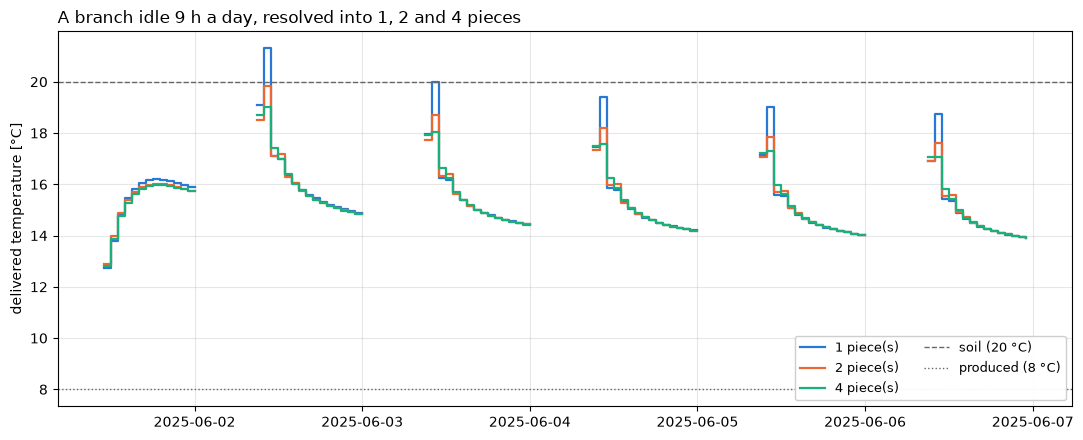

In [9]:
fig, ax = plt.subplots(figsize=(11, 4.5))
for (pieces, (delivered, te)), color in zip(runs.items(), plot.series_colors(3), strict=True):
    ax.step(te[:-1], delivered, where="post", color=color, lw=1.6, label=f"{pieces} piece(s)")
ax.axhline(20.0, color="0.4", ls="--", lw=1.0, label="soil (20 °C)")
ax.axhline(8.0, color="0.4", ls=":", lw=1.0, label="produced (8 °C)")
ax.set_ylabel("delivered temperature [°C]")
ax.set_title("A branch idle 9 h a day, resolved into 1, 2 and 4 pieces", loc="left")
ax.legend(loc="lower right", ncol=2, fontsize=9, framealpha=0.95)
ax.grid(alpha=0.3)
fig.tight_layout()

The first flush of the morning is the warmest water of the day — it has been sitting in the
ground all night — and refining the pipe moves the answer *down* toward the range of its own
inputs rather than away from it. The excursion past the soil is a real property of the model
rather than a bug: the relaxation target is an *effective driving temperature*, and while the
halo is still developing it has to run past the undisturbed soil to reproduce the faster early
exchange. Only `max_sweeps=1` is guaranteed to stay inside the hull of its inputs.

## 5. What left the plant

The whole model is linear in the produced temperature and the surface temperatures, so the
reverse problem is a deconvolution of the same affine operator. Feeding the delivered
temperatures back in should return the production series they came from.

The reverse asks more of the record than the forward direction does. A source bin that no
measurement reaches back to cannot be recovered, and because the deconvolution couples the whole
record, an unconstrained stretch is declined rather than guessed — reporting on the fortnight
alone, as above, leaves the three-week lead-in unmeasured and the solver declines *everything*.
That is the honest answer, not a failure: so here the sensors have been running since the record
opened, and `cout_tedges` spans it all.

The interesting part is what the answer still leaves out. Bins the record does not constrain come
back `NaN`, and so do bins whose reconstruction leans on flux the model had to invent — over a
sensor outage, or past the end of the record, where most of the heat the last bins exchange
arrives after the measurements stop.

In [10]:
measured = source_to_endmember(
    tin=tin,
    flow=demand,
    tedges=tedges,
    cout_tedges=tedges,  # sensors running since the record opened, lead-in included
    network=network,
    soil=SOIL,
    surface_temperature=surface,
    report_nodes=NODES,
)
recovered = endmember_to_source(
    tout=dict(zip(NODES, measured, strict=True)),  # the keys say which taps carry a sensor
    flow=demand,
    tedges=tedges,
    cout_tedges=tedges,
    network=network,
    soil=SOIL,
    surface_temperature=surface,
)
answered = np.isfinite(recovered)
last_answered = int(np.max(np.flatnonzero(answered)))
interior = slice(36, last_answered + 1)

print(f"answered {answered.sum()} of {len(recovered)} bins; declined the last {(~answered).sum()}")
print(
    "max |recovered - produced| over the answered bins after the lead-in: "
    f"{np.nanmax(np.abs(recovered[interior] - tin[interior])):.2e} K"
)

answered 792 of 840 bins; declined the last 48
max |recovered - produced| over the answered bins after the lead-in: 4.23e-05 K


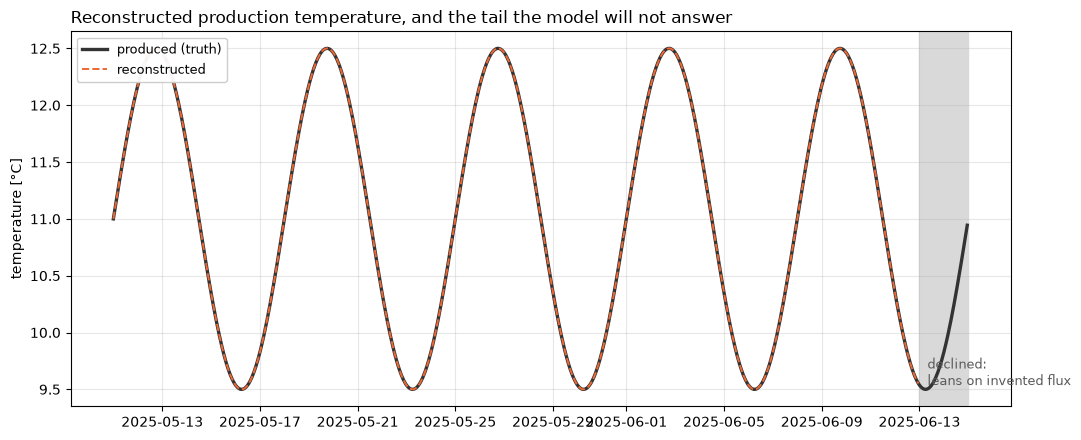

In [11]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(tedges[:-1], tin, color="0.2", lw=2.4, label="produced (truth)")
ax.plot(tedges[:-1], recovered, color=plot.series_colors(2)[1], lw=1.4, ls="--", label="reconstructed")
ax.axvspan(tedges[last_answered + 1], tedges[-1], color="0.85", zorder=0)
ax.text(
    tedges[last_answered + 1],
    tin.min(),
    "  declined:\n  leans on invented flux",
    va="bottom",
    ha="left",
    fontsize=9,
    color="0.35",
)
ax.set_ylabel("temperature [°C]")
ax.set_title("Reconstructed production temperature, and the tail the model will not answer", loc="left")
ax.legend(loc="upper left", fontsize=9, framealpha=0.95)
ax.grid(alpha=0.3)
fig.tight_layout()

Over the interior the reconstruction is exact to the solver's own tolerance. Toward the end it is
not merely less accurate — it is *unconstrained*, and the model says so instead of returning a
confident number. That is the same mechanism that flags a measurement outage: re-solve without
the invented flux, and any bin whose answer moves is one the record does not support.

## Where to go next

- `pipetransport.heat` — the module docstring states the validity limits and what has been
  measured against them
- The user guide's *Assumptions* page — one wall-flux history per pipe, the effective driving
  target, and what each costs
- `03_Heat_Exchange_Conceptual_Model.ipynb` — the same physics in pictures, with no equations